📘 Load Generated Data

In [74]:
# Load datasets
logs = pd.read_csv("C:/Users/pepe/sports-tech-analytics/Project 1/data/platform_logs.csv", parse_dates=['timestamp'])
events = pd.read_csv("C:/Users/pepe/sports-tech-analytics/Project 1/data/sports_events.csv", parse_dates=['event_timestamp'])
activity = pd.read_csv("C:/Users/pepe/sports-tech-analytics/Project 1/data/user_activity.csv", parse_dates=['timestamp'])

print("Datasets loaded successfully.")


Datasets loaded successfully.


🟦 Dataset 1: platform_logs.csv

Purpose: Simulates system‑level platform performance logs (uptime, latency, errors).

| Column | Meaning |
| --- | --- |
| **log_id** | Unique identifier for each log entry. |
| **timestamp** | Exact time the system event was recorded. |
| **latency_ms** | Response time of the platform in milliseconds. |
| **endpoint** | API endpoint or system module accessed. |
| **status** | Whether the request succeeded or failed. |
| **error_type** | Type of error when status = "error". |

🟦 Dataset 2: sports_events.csv

Purpose: Simulates match events (passes, shots, tackles, sprints) for sports analytics.

| Column | Meaning |
| --- | --- |
| **event_id** | Unique identifier for each sports event. |
| **match_id** | Match the event belongs to (e.g., M1, M2). |
| **player_id** | Player who performed the event. |
| **event_type** | Type of event (pass, shot, tackle, sprint). |
| **event_timestamp** | Time during the match when the event occurred. |

🟦 Dataset 3: user_activity.csv

Purpose: Simulates platform usage by coaches, players, and analysts.

| Column | Meaning |
| --- | --- |
| **user_id** | Unique identifier for each user. |
| **role** | User type (coach, player, analyst). |
| **action** | Activity performed (login, upload, review, annotate). |
| **timestamp** | Time the user performed the action. |

🟩 What this gives:

System performance data

Match event data

User behaviour data

#### EDA

In [75]:
# display first few rows of each datasets
print("\nPlatform Logs:")
print(logs.head())

# display first few rows of each datasets
print("\nSports Events:")
print(events.head())

# display first few rows of each datasets
print("\nUser Activity:")
print(activity.head())



Platform Logs:
   log_id           timestamp  latency_ms    endpoint   status  error_type  \
0       1 2025-01-01 00:00:00  289.737132  /analytics  success        none   
1       2 2025-01-01 00:01:00  238.938856     /events  success        none   
2       3 2025-01-01 00:02:00  301.815083  /analytics    error  auth_error   
3       4 2025-01-01 00:03:00  371.842389      /login  success        none   
4       5 2025-01-01 00:04:00  231.267730  /analytics  success        none   

         date  
0  2025-01-01  
1  2025-01-01  
2  2025-01-01  
3  2025-01-01  
4  2025-01-01  

Sports Events:
   event_id match_id player_id event_type     event_timestamp
0         1       M2       P21     tackle 2025-01-01 00:10:04
1         2      M19       P13       shot 2025-01-01 00:38:08
2         3      M19       P47       pass 2025-01-01 01:23:38
3         4      M19       P11     tackle 2025-01-01 01:24:31
4         5      M18       P49     sprint 2025-01-01 00:52:20

User Activity:
  user_id     r

In [76]:
# inspect data types and missing values
print("\nPlatform Logs Info:")
print(logs.info())
print("\nSports Events Info:")
print(events.info())
print("\nUser Activity Info:")
print(activity.info())



Platform Logs Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   log_id      5000 non-null   int64         
 1   timestamp   5000 non-null   datetime64[ns]
 2   latency_ms  5000 non-null   float64       
 3   endpoint    5000 non-null   object        
 4   status      5000 non-null   object        
 5   error_type  5000 non-null   object        
 6   date        5000 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 273.6+ KB
None

Sports Events Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   event_id         3000 non-null   int64         
 1   match_id         3000 non-null   object        
 2   player_id

📊 1. Platform Health KPIs

In [77]:
# Uptime %. the percentage of logs that are successful
uptime = (logs['status'] == 'success').mean() * 100
print(f"\nSystem Uptime: {uptime:.2f}%")

# Average latency. Calculate the mean latency for all logs and print it in milliseconds.
avg_latency = logs['latency_ms'].mean()
print(f"\nAverage Latency: {avg_latency:.2f} ms")


# Error rate. Calculate the percentage of logs that have a status of 'error' and print it.
error_rate = (logs['status'] == 'error').mean() * 100
print(f"\nError Rate: {error_rate:.2f}%")

# Errors by endpoint. Group the logs by 'endpoint' and count the number of logs with a status of 'error' for each endpoint. Print the results.
errors_by_endpoint = logs[logs['status'] == 'error'].groupby('endpoint').size()
print("\nErrors by Endpoint:")
print(errors_by_endpoint)




System Uptime: 89.92%

Average Latency: 250.62 ms

Error Rate: 10.08%

Errors by Endpoint:
endpoint
/analytics    122
/events       106
/login        141
/upload       135
dtype: int64


📈 2. Latency Trend

In [78]:
# Latency trend over time. Group the logs by date (you can extract the date from the 'timestamp' column) and calculate the average latency for each date. Print the results.
logs['date'] = logs['timestamp'].dt.date
latency_trend = logs.groupby('date')['latency_ms'].mean()

print("\nLatency Trend Over Time:")
print(latency_trend.head())



Latency Trend Over Time:
date
2025-01-01    253.304128
2025-01-02    252.253655
2025-01-03    247.185559
2025-01-04    248.727309
Name: latency_ms, dtype: float64


⚽ 3. Match & Player Event KPIs

In [79]:
# Events per match
events_per_match = events.groupby('match_id').size()
print("\nEvents per Match:")
print(events_per_match.head())


# Events by type
events_by_type = events['event_type'].value_counts()
print("\nEvents by Type:")
print(events_by_type)

# Events per player
events_per_player = events.groupby('player_id').size()
print("\nEvents per Player:")
print(events_per_player.head())



Events per Match:
match_id
M1     151
M10    140
M11    141
M12    155
M13    166
dtype: int64

Events by Type:
event_type
pass      830
sprint    752
tackle    728
shot      690
Name: count, dtype: int64

Events per Player:
player_id
P1     52
P10    50
P11    73
P12    65
P13    58
dtype: int64


👥 4. User Activity KPIs

In [80]:
# Daily active users. 
# Group the activity logs by date (you can extract the date from the 'timestamp' column) and count the number of unique users (user_id) for each date. Print the results.
activity['date'] = activity['timestamp'].dt.date
daily_active_users = activity.groupby('date')['user_id'].nunique()
print("\nDaily Active Users:")
print(daily_active_users.head())


# Actions by role. Group the activity logs by 'role' and count the number of actions for each role. Print the results.
actions_by_role = activity.groupby('role').size()
print("\nActions by Role:")
print(actions_by_role)


# Most common actions. Group the activity logs by 'action' and count the number of occurrences for each action type. Print the results.
actions_by_type = activity['action'].value_counts()
print("\nActions by Type:")
print(actions_by_type)



Daily Active Users:
date
2025-01-01     99
2025-01-02    100
2025-01-03    100
2025-01-04    100
2025-01-05     99
Name: user_id, dtype: int64

Actions by Role:
role
analyst    1355
coach      1308
player     1337
dtype: int64

Actions by Type:
action
annotate    1022
review      1003
upload       995
login        980
Name: count, dtype: int64


📌 5. Sanity‑Check Visuals

These help confirm the synthetic data looks realistic.

C:\Users\pepe\AppData\Local\Temp\ipykernel_18484\367615370.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


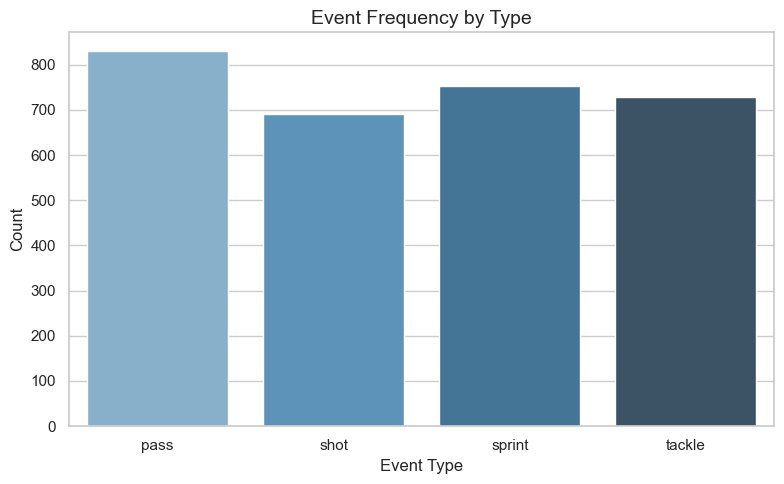

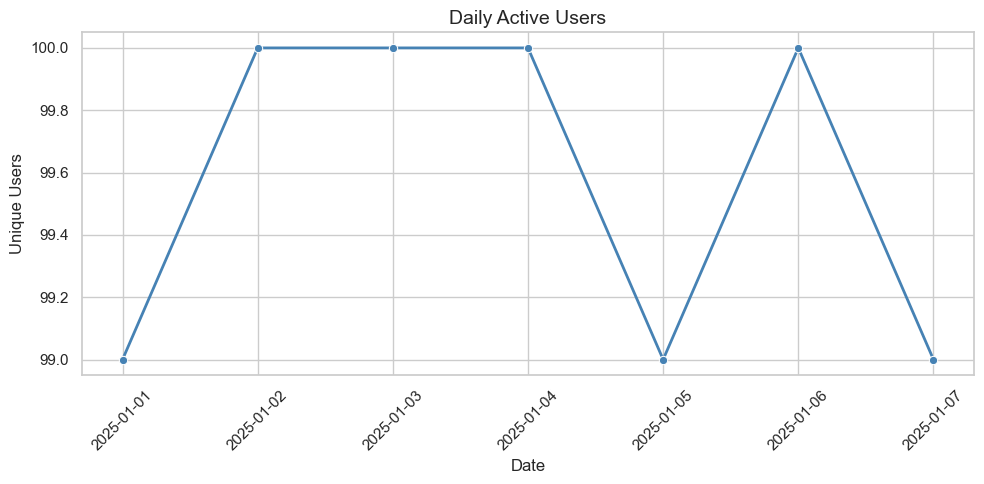

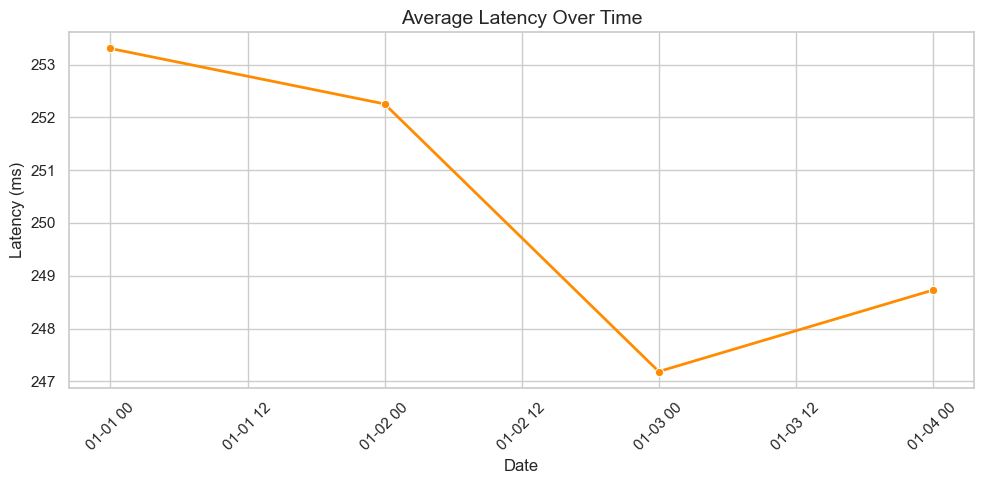

In [81]:
# Visualizations - Use matplotlib or seaborn to create visualizations for the following:

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# -----------------------------
# Event Frequency by Type
# -----------------------------
plt.figure(figsize=(8,5))
events_by_type_sorted = events['event_type'].value_counts().sort_index()

sns.barplot(
    x=events_by_type_sorted.index,
    y=events_by_type_sorted.values,
    palette="Blues_d"
)

plt.title("Event Frequency by Type", fontsize=14)
plt.xlabel("Event Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()


# -----------------------------
# Daily Active Users
# -----------------------------
plt.figure(figsize=(10,5))

sns.lineplot(
    x=daily_active_users.index,
    y=daily_active_users.values,
    marker="o",
    linewidth=2,
    color="steelblue"
)

plt.title("Daily Active Users", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Unique Users", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# -----------------------------
# Average Latency Over Time
# -----------------------------
plt.figure(figsize=(10,5))

sns.lineplot(
    x=latency_trend.index,
    y=latency_trend.values,
    marker="o",
    linewidth=2,
    color="darkorange"
)

plt.title("Average Latency Over Time", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Latency (ms)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


📊 Sanity‑Check Visuals Explanations

1. Event Frequency by Type

This chart shows how often each event (pass, shot, tackle, sprint) occurs in the dataset, helping confirm the event distribution looks realistic.

2. Daily Active Users

This line chart shows how many unique users logged in each day, giving a quick check that user activity trends look consistent and believable.

3. Average Latency Over Time

This chart tracks the system’s average response time each day, helping you spot performance spikes or unusual slowdowns.

For Power BI 

2️⃣ Create Relationships
Go to Model View and set:

platform_logs
(no relationships needed — standalone system metrics)

sports_events
match_id → no external table (self‑contained)

player_id → no external table

user_activity
(no relationships needed — standalone behaviour table)

Because these datasets represent three independent analytical domains, they do not need relationships.
This is normal for monitoring dashboards.